In [1]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("data_repeta_reprod-3.csv")
data.Test_2.value_counts(True)

Test_2
Valide    0.515939
refus     0.484061
Name: proportion, dtype: float64

# 1. Exploratory Data Analysis
## Objectif :
- Comprendre du mieux possible nos données 
- Développer une premiere stratégie de modélisation
## Checklist de base
#### Analyse de Forme :
- **variable target** : Moyenne CFL C
- **lignes et colonnes** : (1055, 10)
- **types de variables** :7 de type float, 1 de type entier, et 2 de type Chaine de caratere
- **Analyse des valeurs manquantes** : Pas de valeurs manquantes


In [3]:
data[data.Test_2 == "Valide"].Contaminant.value_counts()

Contaminant
NC.C.                232
Neige fraiche (B)    191
N.C. (B)             140
Neige fraiche (G)    129
Glace                107
N.C. (G)             106
SLUSH                 70
Verglas               58
DRY                   19
Name: count, dtype: int64

- une seule machine qui est "208 G 117" (Var machine)
- Pneumatique aussi une seule valeur; "Pneu rainuré PEX Mt St Dauphin" (var pneumatique)
- Décalage/Axe: une seule valeur; 0 (var Decalage/axe)
- Les variables suivantes sont inutiles pour notre analyse:
      'Machine', 'Pneumatique','Nom du Curseur', 'Seuil de départ', 'Position/Axe', 'Décalage/Axe', 
       'Date', 'Date_txt', 'Heure', 'Heure_txt', 'Pas Min [m]', 'Pas Max [m]', 'ET G%', 'Ic G%','ET CFLF',
       'ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv'


- T° BDR (V) contenait des valeurs bizzares (56 observations index entre 20 et 26, 299 et 347) lors d'une erreur du fichier originale, ces erreurs sont corrigées, apres, cette variable est transformé en type float






In [4]:
# Filtrer les lignes où 'Test_2' est 'Valide' et réinitialiser l'index
df = data[data.Test_2 == "Valide"].reset_index(drop=True).copy()
# Supprimer les colonnes spécifiées
df = df.drop(["Test", "180 - Fv", "Test_2"], axis=1)

columns_to_drop = ['Machine', 'Pneumatique','Nom du Curseur', 'Seuil de départ', 'Position/Axe', 'Décalage/Axe', 
                   'Date', 'Date_txt', 'Heure', 'Heure_txt', 'Pas Min [m]', 'Pas Max [m]', 'Moyenne Vitesse [Km/h]', 
                   'ET G%', 'Ic G%','ET CFLF','ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv']
df = df.drop(columns_to_drop, axis = 1)


def contient_chaine(variable):
    """
    Vérifie si la chaîne contient des caractères autres que des chiffres et le point décimal.
    
    Args:
    variable (str): La chaîne de caractères à vérifier.
    
    Returns:
    bool: True si la chaîne contient des caractères non numériques, False sinon.
    """
    return any(not (char.isdigit() or char == '.') for char in variable)

#Résoudre le probleme liée à la base de donnée quant à la variable T° BDR (V)
df.loc[df["T° BDR (V)"].apply(contient_chaine), "T° BDR (V)"] = 1.74296285714286
# Convertir la colonne 'T° BDR (V)' en type float
df["T° BDR (V)"] = df["T° BDR (V)"].astype(float)




## Transformation des températures en C
df['Tsurf (V)'] = df['Tsurf (V)'] * 11.274 - 31.72
df["T° BDR (V)"] = df["T° BDR (V)"] * 15.5 - 23.55



df = df.rename(columns={
    'Tsurf (V)': 'Tsurf (C)',
    "T° BDR (V)": "T° BDR (C)"
})

In [5]:
# Créer le box plot
display(df["Moyenne CFL C"].describe())
a = lambda x: df.Contaminant.value_counts() if x==0 else df.Contaminant.value_counts(True)
pd.concat([a(0), a(1)*100], axis = 1)

count    1052.000000
mean        0.142208
std         0.078354
min         0.000000
25%         0.097619
50%         0.146429
75%         0.183583
max         0.824905
Name: Moyenne CFL C, dtype: float64

,count,proportion
Contaminant,,
NC.C.,232,22.053232
Neige fraiche (B),191,18.155894
N.C. (B),140,13.307985
Neige fraiche (G),129,12.262357
Glace,107,10.171103
N.C. (G),106,10.076046
SLUSH,70,6.653992
Verglas,58,5.513308
DRY,19,1.806084


In [6]:
ss.skew(df["Moyenne CFL C"])

1.9919260754281345

Le Cfl C dans notre jeu de données varie entre 0 et 0.82, 95% des observations ont un CFL inferieur à 0.25, c'est à dire 5% (pour les valeurs extreme du CFL sont specifique au contaminant 'DRY' ce qui est evident), le skewness de cette dstribution est 2, or la median egale à la moyenne  cela est contre-intuitif, car on s'attendrait normalement à ce que la moyenne soit nettement supérieure à la médiane dans une distribution fortement asymétrique à droite.
Pour la variable contaminant on visualise dans la figure ci dessus l'effectif de chaque contaminat et son pourcentage.
On decide alors de ne pas integrer les observations du contaminant "Dry" pour deux raisons:

    - Le but de ce travail, c'est de modeliser le CFL C (comme etant une variable à expliquer ou explicative) dans les conditions hevernales, son etude sur une surface seche fait l'objet d'autre recherche faite au STAC
    - Ce contaminant constitue moins de 2% des observations de la base de donées avec un effectif de 19 observations, pour la modelisation version apprentissage, c'est ne pas dificile de faire confiance à un modeles entrainé avec moins de 19 observations (apres division en ensemble de test et d'apprentissage)

Pour analyser la relation entre les variables à expliquer et la varibale cible ou les variables entre elles, on va proceder par la visualisation des correlation (voir la figure suivante)

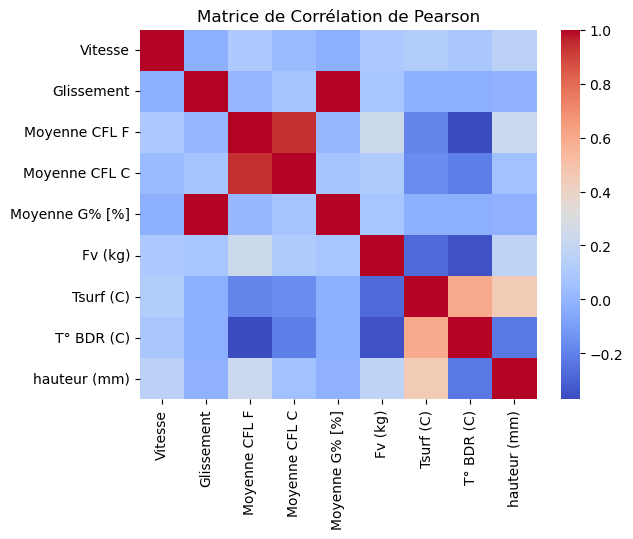

In [7]:
numeric_cols = df.select_dtypes(include=["float", "int"]).columns

# Exclure certaines colonnes spécifiques 
cols_to_exclude = []
numeric_cols = [col for col in numeric_cols if col not in cols_to_exclude]

sns.heatmap(df[numeric_cols].corr(), cmap='coolwarm', fmt=".2f")
plt.title('Matrice de Corrélation de Pearson')
plt.show()


In [8]:
print(df.Glissement.corr(df['Moyenne G% [%]']))
print(df['Moyenne CFL C'].corr(df["Moyenne CFL F"]))


0.9997133189149473
0.9388965933112801


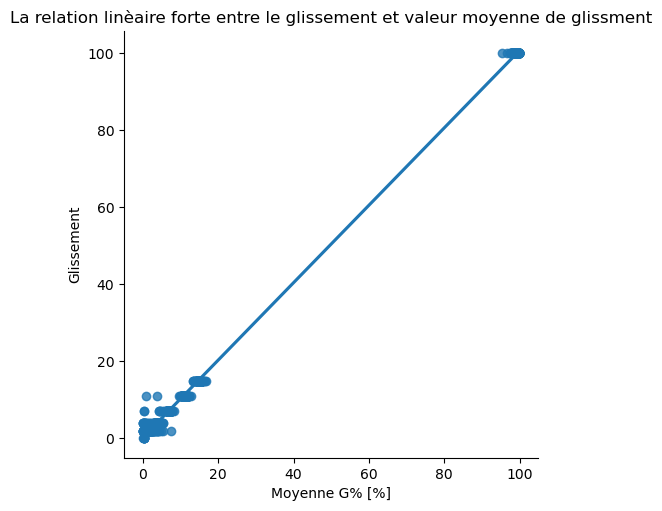

In [9]:
sns.lmplot(x='Moyenne G% [%]', y = "Glissement", data = df)
plt.title("La relation linèaire forte entre le glissement et valeur moyenne de glissment")
plt.show()

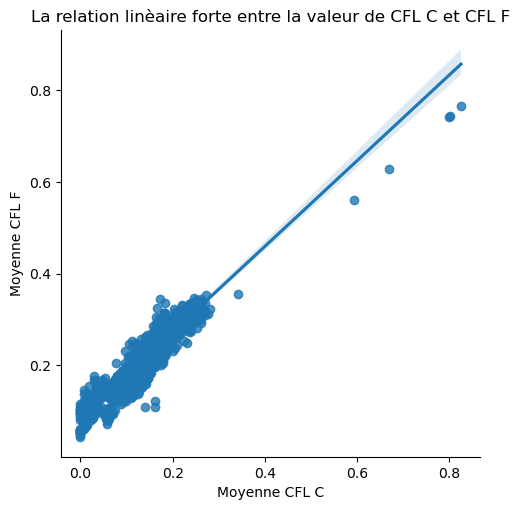

In [10]:
sns.lmplot(x='Moyenne CFL C', y = "Moyenne CFL F", data = df)
plt.title("La relation linèaire forte entre la valeur de CFL C et CFL F")
plt.show()

### Remarques

- **Corrélation entre Glissement et Moyenne Glissement** :
  - Une corrélation extrêmement élevée (0.99987) existe entre "Glissement" et "Moyenne Glissement". Ces variables sont quasiment interchangeables en termes d'information qu'elles apportent, on peut constater un manque des valeurs du glisement dans l'intervalle 20 et 100. on peut voir la relation entre ces deux variables dans le graphe suivant.

- **Relation Linéaire entre CFL C et CFL F** :
  - Il y a une relation linéaire marquée entre "CFL C" et "CFL F", avec une corrélation de 0.93. Cela suggère que ces deux variables sont fortement liées.

- **Faible Corrélation entre les Variables Explicatives** :
  - Les différentes variables explicatives montrent une faible corrélation entre elles, ce qui est bénéfique pour réduire la multicolinéarité et améliorer la performance du modèle.

- **Faible Corrélation entre la Variable Cible et les Variables Explicatives** :
  - La variable cible présente une faible corrélation avec les variables explicatives, indiquant que les relations entre elles ne sont probablement pas linéaires.


### Commentaires 

- **Glissement et Moyenne Glissement** :
  - Les variables "Glissement" et "Moyenne Glissement" fournissent également la même information. Toutefois, "Moyenne Glissement" est plus précise. Il est difficile de considérer "Glissement" comme une version discrétisée de "Moyenne Glissement" en raison du nombre élevé de modalités (7). Par conséquent, il est essentiel de supprimer l'une des deux variables lors de la modélisation pour améliorer la précision. Nous supprimerons "Glissement" en faveur de "Moyenne Glissement" pour garder la precision et la flexibilité des modeles.
  - Lors des mesures, seuls les glissement consignes 2, 4, 7, 11, 15  et 100 ont ete choisit à etre mesuré pour une vitesse donnée, la courbe du CFL C en fonction du glissement devrait montrer un plateau ou une courbe faiblement décroissante dans l'intervalle 20 et 100, dans cette intervalle les valeurs de CFL sont proches de la valeur maximale de glissement mais légèrement supérieures.
  - Cette remarque (manque des observations) va etre tres importante pour le choix du modele de regression qui doit respecter certaines contraintes (voir la partie de modélisation).

- **Décorrélation des Variables Explicatives** :
   Le fait que les variables explicatives soient décorrélées est un point fort pour la modélisation car :
    - Chaque variable apporte une information distincte des autres, ce qui réduit la complexité du modèle.
    - Une complexité réduite signifie une variance faible, ce qui conduit à une meilleure précision et à un risque de sur-apprentissage réduit.

- **Faible Corrélation entre les Variables Explicatives et la Variable Cible** :
  - La faible corrélation entre les variables explicatives et la variable cible est un point faible pour la modélisation linéaire car :
    - La relation entre la variable cible et les autres variables n'est pas linéaire.
    - Cette observation suggère l'utilisation d'une régression polynomiale pour mieux capturer les relations non linéaires.
   

- **Variable CFL F** :
  -  On ne ca pas utiliser cette variable pour la regression ni pour la classification (il ne va que complexer le modele vue sa grande correlation avec le CFL C), mais on va la garder pour une prochine analyse.
- **Température**:
    - On transformer les température du volt (v) en degre celisius en utilisant ces formules: 'Tsurf (V)' = 'Tsurf (V)' * 11.274 - 31.72
"T° BDR (V)" = "T° BDR (V)" * 15.5 - 23.55

In [11]:
df_cflf = df.copy()
df_cflf = df_cflf.drop(['Glissement','Fv (kg)', 'Tsurf (C)', 'T° BDR (C)','hauteur (mm)','Vitesse', 'Moyenne G% [%]'],axis = 1)
df_cflf["Diff"] = df_cflf['Moyenne CFL F']-df_cflf['Moyenne CFL C']


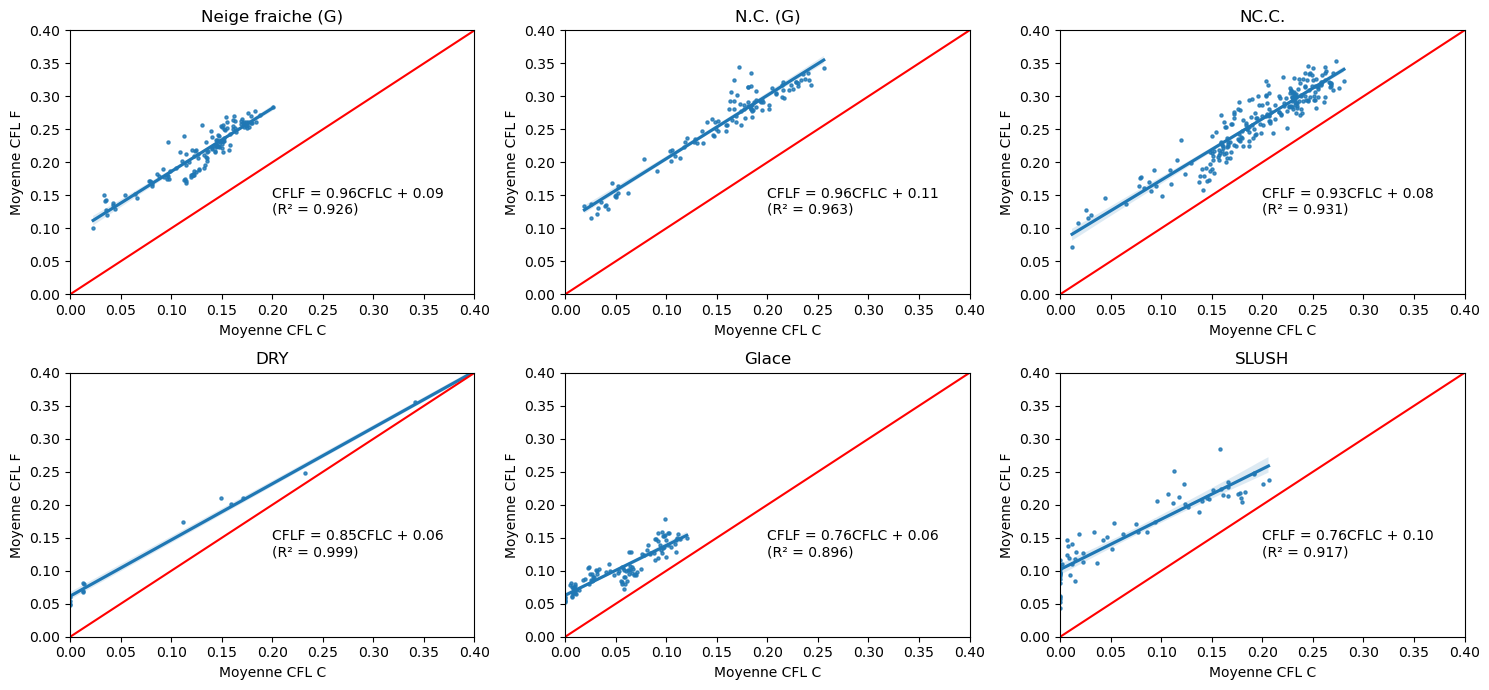

In [12]:
from scipy.stats import linregress

x = [0, 1]
a = 1
unique_contaminants = df_cflf.Contaminant.unique()
num_plots = len(unique_contaminants)

plt.figure(figsize=(15, 7))  # Ajuster la taille de la figure pour mieux afficher les subplots
c = ['Neige fraiche (G)','N.C. (G)' , 'NC.C.','DRY', 'Glace', 'SLUSH']
for i in c:
    plt.subplot(2, 3, a)
    
    # Filtrer les données pour le contaminant actuel
    data = df_cflf[df_cflf.Contaminant == i]
    
    # Calculer la régression linéaire
    slope, intercept, r_value, p_value, std_err = linregress(data['Moyenne CFL C'], data['Moyenne CFL F'])
    
    # Tracer la droite de régression et les points de données
    sns.regplot(x='Moyenne CFL C', y='Moyenne CFL F', data=data, scatter_kws={'s': 5})
    
    # Ajouter la ligne y = x en rouge
    plt.plot(x, x, c="r")
    
    # Ajouter l'équation de la droite de régression
    equation = f'CFLF = {slope:.2f}CFLC + {intercept:.2f} \n(R² = {round(r_value,3)})'
    plt.text(0.5, 0.35, equation, horizontalalignment='left', verticalalignment='center', transform=plt.gca().transAxes)
    
    # Définir les limites des axes
    plt.xlim(0, 0.4)
    plt.ylim(0, 0.4)
    
    # Ajouter le titre
    plt.title(i)
    
    a += 1

plt.tight_layout()
plt.show()


In [13]:
df_cflf.columns

Index(['Moyenne CFL F', 'Moyenne CFL C', 'Contaminant', 'Diff'], dtype='object')

Text(0, 0.5, 'CFL F - CFL C')

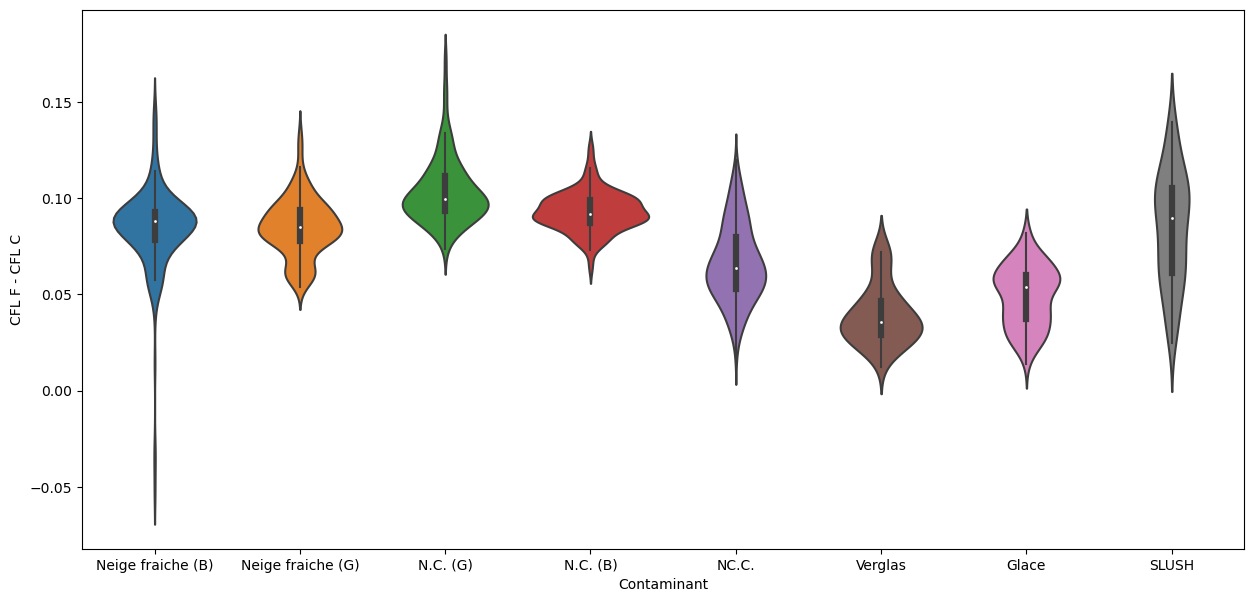

In [14]:
plt.figure(figsize=(15, 7))
sns.violinplot(x= 'Contaminant', y = "Diff", data = df_cflf[df_cflf["Contaminant"] != "DRY"])
plt.ylabel("CFL F - CFL C")

In [73]:
from scipy.stats import f_oneway

# Copie du DataFrame et suppression des colonnes non nécessaires
df_cflf = df.copy()
df_cflf = df_cflf.drop(['Glissement','Fv (kg)', 'Tsurf (C)', 'T° BDR (C)','hauteur (mm)','Vitesse', 'Moyenne G% [%]'], axis=1)

# Calcul de la différence entre les moyennes
df_cflf["Diff"] = df_cflf['Moyenne CFL F'] - df_cflf['Moyenne CFL C']

# Copie du DataFrame pour manipulation
data = df_cflf.copy()

# Filtrage des données par contaminant
v = data[data['Contaminant'] == "Verglas"]['Diff'].to_list()
nfb = data[data['Contaminant'] == 'Neige fraiche (B)']['Diff'].to_list()
nfg = data[data['Contaminant'] == 'Neige fraiche (G)']['Diff'].to_list()
ncb = data[data['Contaminant'] == 'N.C. (B)']['Diff'].to_list()
ncg = data[data['Contaminant'] == 'N.C. (G)']['Diff'].to_list()
ncc = data[data['Contaminant'] == 'NC.C.']['Diff'].to_list()
g = data[data['Contaminant'] == 'Glace']['Diff'].to_list()
s = data[data['Contaminant'] == 'SLUSH']['Diff'].to_list()
d = data[data['Contaminant'] == 'DRY']['Diff'].to_list()

# Fonction pour réaliser l'ANOVA
def anova_test(*groups):
    alpha = 0.05
    stat, p = f_oneway(*groups)
    if p < alpha:
        return (p, "Oui")
    else:
        return (p, "Non")

# Appel de la fonction anova_test pour comparer plusieurs groupes
resultat_anova = anova_test(v, nfb, nfg, ncb, ncg, ncc, g, s, d)
print("ANOVA result:", resultat_anova)


ANOVA result: (3.592376737881329e-143, 'Oui')


In [19]:
df.columns


Index(['Vitesse', 'Glissement', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'Tsurf (C)', 'T° BDR (C)', 'Contaminant',
       'hauteur (mm)'],
      dtype='object')

In [24]:
df.to_csv("Data_Modelisation-3.csv", index=False)

In [25]:
df.Contaminant.value_counts()

Contaminant
NC.C.                232
Neige fraiche (B)    191
N.C. (B)             140
Neige fraiche (G)    129
Glace                107
N.C. (G)             106
SLUSH                 70
Verglas               58
DRY                   19
Name: count, dtype: int64

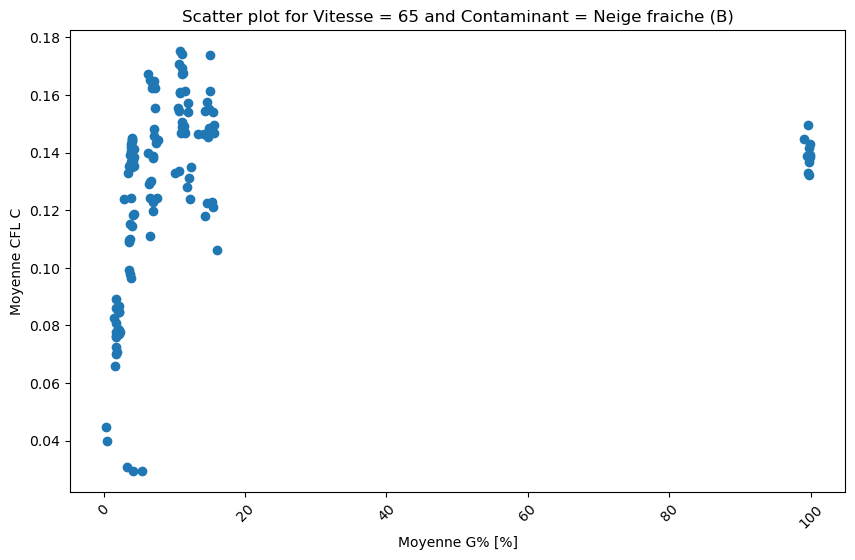

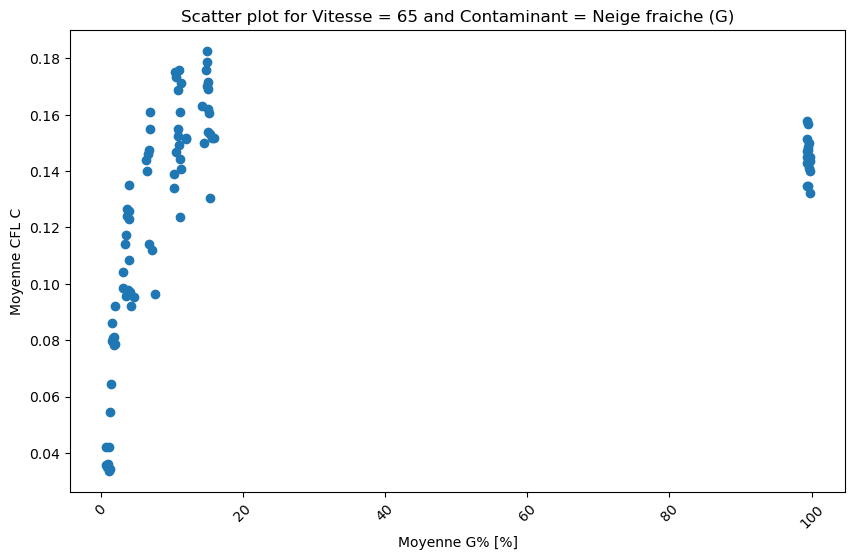

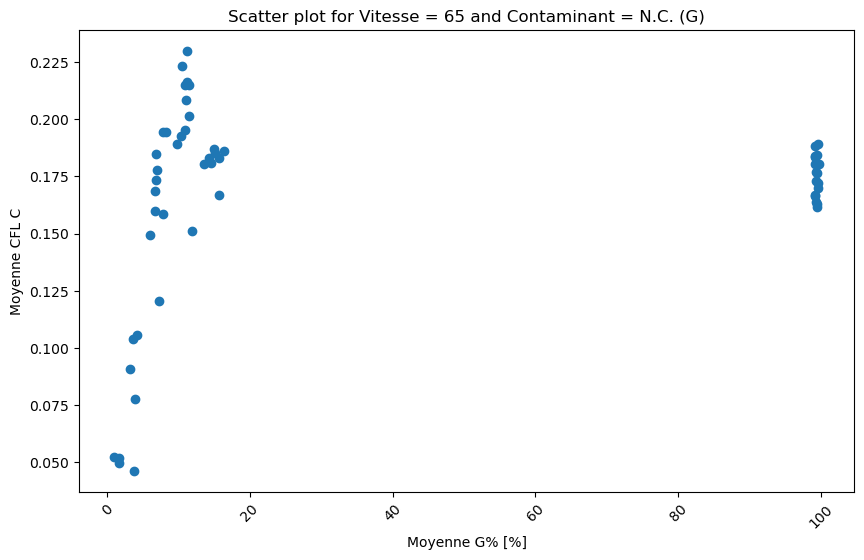

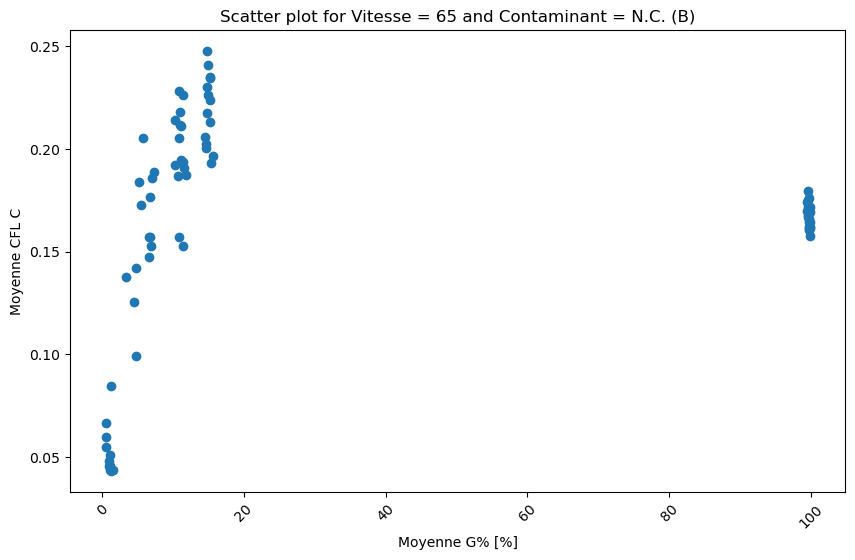

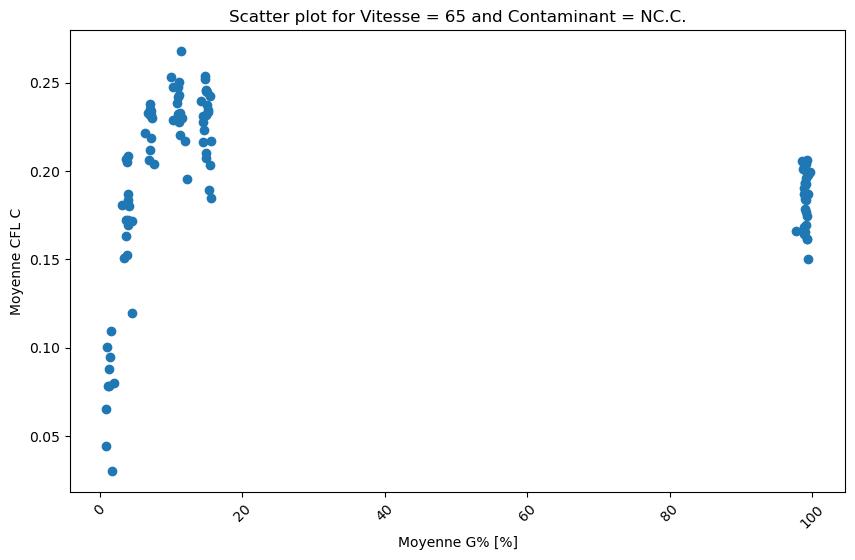

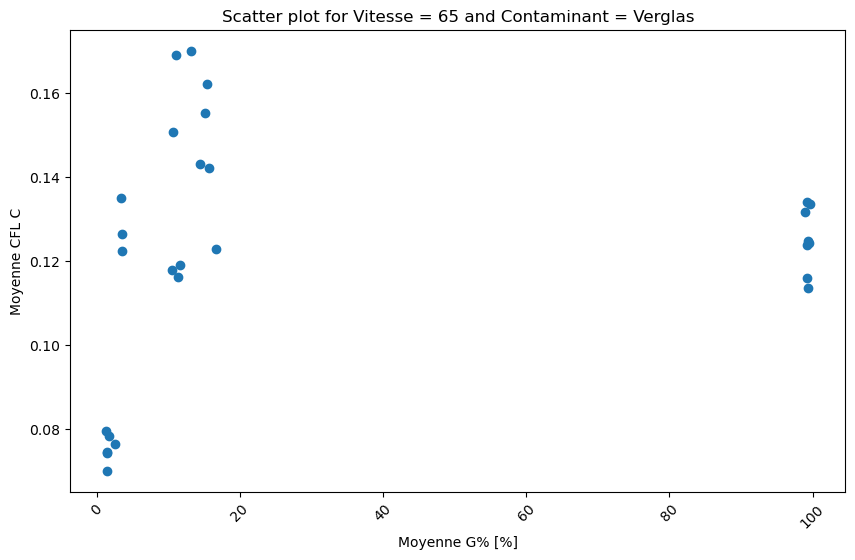

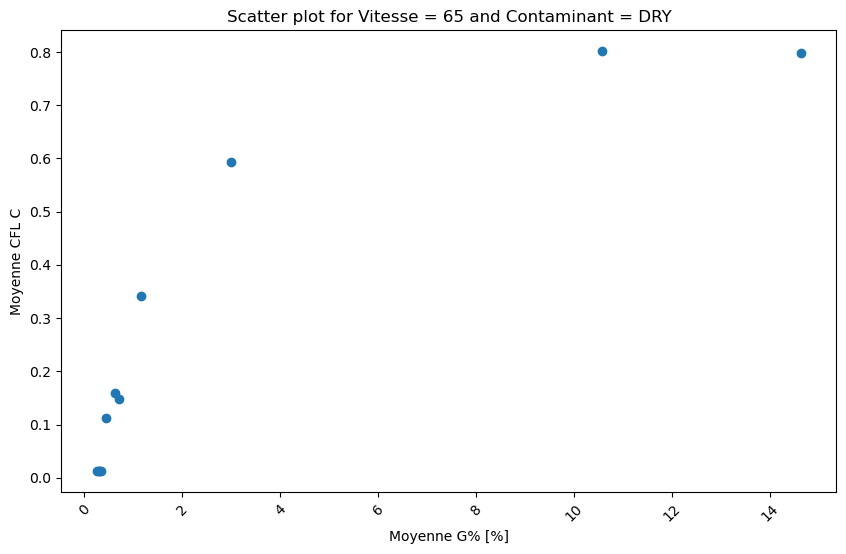

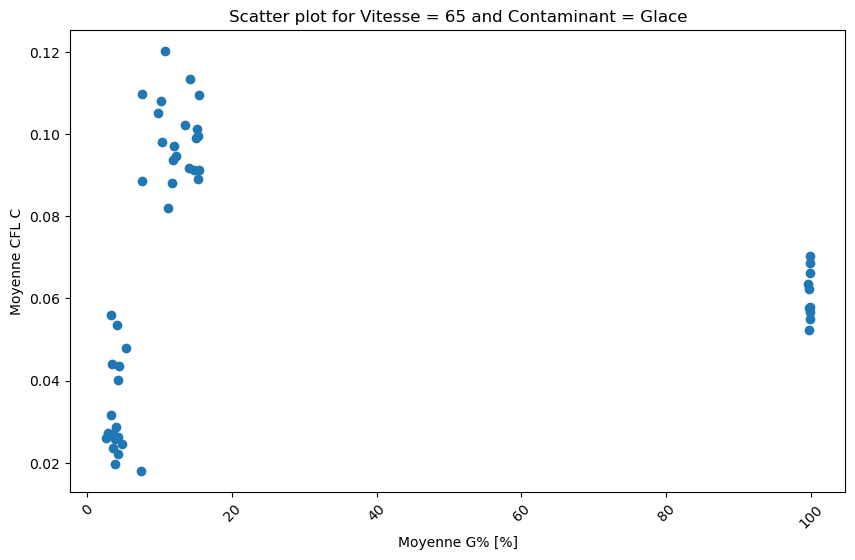

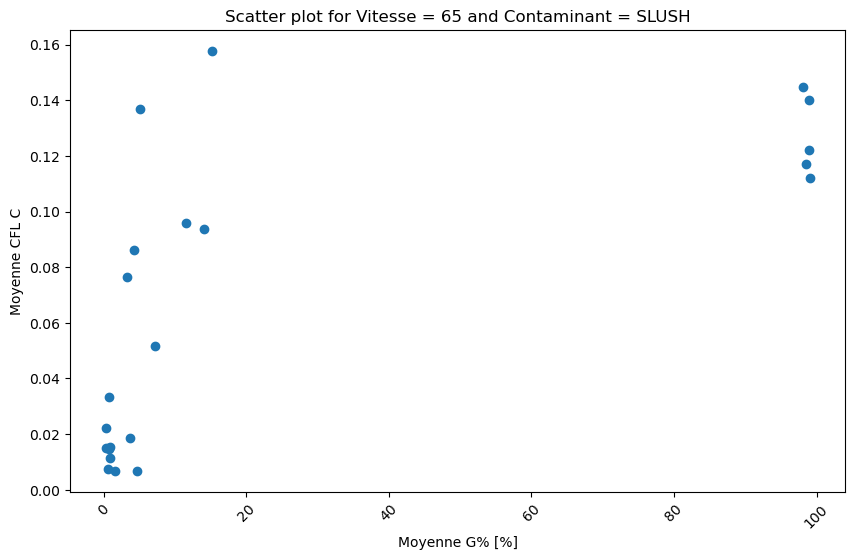

In [26]:
for i in df.Contaminant.unique():
    plt.figure(figsize=(10, 6))
    v = 65
    c = i
    x_data = df[(df.Vitesse == v) & (df.Contaminant == i)]["Moyenne G% [%]"]
    y_data = df[(df.Vitesse == v) & (df.Contaminant == c)]["Moyenne CFL C"]
    
    plt.scatter(x_data, y_data)
    plt.xlabel("Moyenne G% [%]")
    plt.ylabel("Moyenne CFL C")
    plt.title(f"Scatter plot for Vitesse = {v} and Contaminant = {c}")
    
    # Optionnel: définir les graduations de l'axe des x
    plt.xticks(rotation=45)  # Exemple : rotation des graduations pour une meilleure lisibilité
    
    plt.show()
